# 01 曲线与导数栈

**本节回答**

1. 插补器为什么需要把 $\mathbf{C}$、$\mathbf{C}'$、$\mathbf{C}''$、$\mathbf{C}'''$ 一次同时求出？
2. 全库通用的导数栈 `(4, ..., dim)` 是什么，`d[k]` 为什么不是 Taylor 系数？
3. 对参数 $u$ 求导与对弧长 $s$ 求导差在哪里，怎么换算？
4. 曲线在哪些点"不光滑"，库靠什么记住它们？
5. 怎么把一条曲线精确地切成两段？

**前置知识**：无，这是第一本。下一本 [02 弧长表与进给波动](02_弧长表与进给波动.ipynb) 讲怎样把"时间"换算成曲线参数。

环境约定：内部一律 mm、rad（本节不出现时间）；图里文字用英文。

In [1]:
import os.path as osp
import sys
from pathlib import Path

import matplotlib.pyplot as plt

root_path = Path(osp.abspath("")).parents[0]
sys.path.append(str(root_path))

%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np

import cnc5x as cx
from cnc5x import plotting

plotting.use_style()

## 1. 为什么是"导数栈"

周期插补是每个插补周期 $T_s$ 算一个刀位点。速度规划先给出弧长随时间的函数及其变化率 $[s, v, a, j]$；要落出刀尖的位置、速度、加速度和 jerk，还得把曲线对弧长的导数 $[\mathbf{C}_s, \mathbf{C}_{ss}, \mathbf{C}_{sss}]$ 乘上它们：

$$
\begin{aligned}
\dot{\mathbf{C}} &= \mathbf{C}_s\,v,\\
\ddot{\mathbf{C}} &= \mathbf{C}_{ss}\,v^2 + \mathbf{C}_s\,a,\\
\dddot{\mathbf{C}} &= \mathbf{C}_{sss}\,v^3 + 3\mathbf{C}_{ss}\,va + \mathbf{C}_s\,j .
\end{aligned}
$$

刀具每一点的 **速度、加速度、jerk** 决定机床轴会不会超限、跟踪精度如何，所以 0 到 3 阶导数是"同样重要的一伙"，要成组提供。cnc5x 把它固定成一种表示——**导数栈**：

- 形状 `(4, ..., dim)`，`d[k]` 是 **第 $k$ 阶导数本身**，$d[0]$ 就是函数值；
- `d[k]` **不是** Taylor 系数 $\mathbf{f}^{(k)}/k!$——Taylor 公式里那个 $k!$ 自己除，库里不作约定；
- 对参数、对弧长、对时间求导，都用同一个形状，靠第 4 节的链式法则换算。

约定细节见 [docs/数学约定.md](../docs/数学约定.md) 第 1 节。

子类只需实现 `_derivatives(u, order)`，一次返回 0 到 `order` 阶的一叠；`u` 可以是标量或任意形状的数组，求值对整批点一次性完成。先看形状。

In [3]:
line = cx.Line([0, 0], [3, 4])  # 参数 u ∈ [0, 1] 的直线段
for u in (0.5, np.linspace(0, 1, 5), np.zeros((2, 3))):
    print(f"u 的形状 {np.shape(u)}  ->  导数栈 {line.derivatives(u).shape}")

u 的形状 ()  ->  导数栈 (4, 2)
u 的形状 (5,)  ->  导数栈 (4, 5, 2)
u 的形状 (2, 3)  ->  导数栈 (4, 2, 3, 2)


**为什么一次求一叠，而不是一阶一阶地要**：NURBS（有理曲线）的 $k$ 阶导数要先用齐次坐标的 **全部低阶导数** 递推出来（`NURBS._derivatives` 里的 Leibniz 递推，The NURBS Book §4.3）；单位化、复合函数同理。逐阶单独求会把低阶部分重复算几遍——文档里给过账：五轴刀位曲线一次求值要多调用两倍多的 B 样条。`order` 参数则让只求点的调用（`curve(u)`）不被迫去算高阶。

**要点**：全库只有一种导数表示 `(4, ..., dim)`，第 $k$ 层是第 $k$ 阶导数；高阶依赖低阶，所以"求一叠"是基本操作。

## 2. 四种基本曲线

一次认识本节用到的四条曲线（其中 B 样条与整圆沿用 `examples/curves.py`）：

- **Line**：$\mathbf{C}(u) = \mathbf{P}_0 + u(\mathbf{P}_1 - \mathbf{P}_0)$，最朴素的插补段；
- **Bezier**：控制点即 Bernstein 系数，端点插值，常用于拐角过渡曲线；
- **BSpline**：分段多项式，节点（knot）处高阶导数降连续性，本节主例；
- **NURBS**：有理 B 样条，能**精确**表示圆——九控制点、权重 $1,\sqrt2/2$ 交错的二次 NURBS 拼出整圆。

In [4]:
ctrl = [[0, 0], [10, 25], [25, -10], [40, 30], [55, 0], [70, 20]]  # mm
line = cx.Line([0, 0], [70, 20])
bezier = cx.Bezier([[0, 0], [40, 35], [60, -5], [70, 20]])
bspline = cx.BSpline(ctrl, degree=3)  # 均匀夹持节点，参数域 [0, 1]

w = np.sqrt(0.5)  # NURBS 整圆：四段二次有理 Bézier，权重 1、√2/2 交错
circle = cx.NURBS(
    [[1, 0], [1, 1], [0, 1], [-1, 1], [-1, 0], [-1, -1], [0, -1], [1, -1], [1, 0]],
    degree=2,
    knots=[0, 0, 0, 0.25, 0.25, 0.5, 0.5, 0.75, 0.75, 1, 1, 1],
    weights=[1, w, 1, w, 1, w, 1, w, 1],
)
for c, name in ((line, "Line"), (bezier, "Bezier"), (bspline, "BSpline"), (circle, "NURBS")):
    print(f"{name:8s} domain={c.domain}, breaks={np.round(c.breaks, 3)}")
print(bspline, f"弧长 {bspline.length:.2f} mm")

r = np.linalg.norm(circle(np.linspace(0, 1, 201)), axis=1)
print(f"NURBS 整圆半径 ∈ [{r.min():.15f}, {r.max():.15f}]")
assert abs(r.min() - 1) < 1e-14 and abs(r.max() - 1) < 1e-14  # 有理曲线表示的圆是精确的

Line     domain=(0.0, 1.0), breaks=[0. 1.]
Bezier   domain=(0.0, 1.0), breaks=[0. 1.]
BSpline  domain=(0.0, 1.0), breaks=[0.    0.333 0.667 1.   ]
NURBS    domain=(0.0, 1.0), breaks=[0.   0.25 0.5  0.75 1.  ]
BSpline(degree=3, 6 control points, domain=(0.0, 1.0)) 弧长 88.88 mm
NURBS 整圆半径 ∈ [1.000000000000000, 1.000000000000000]


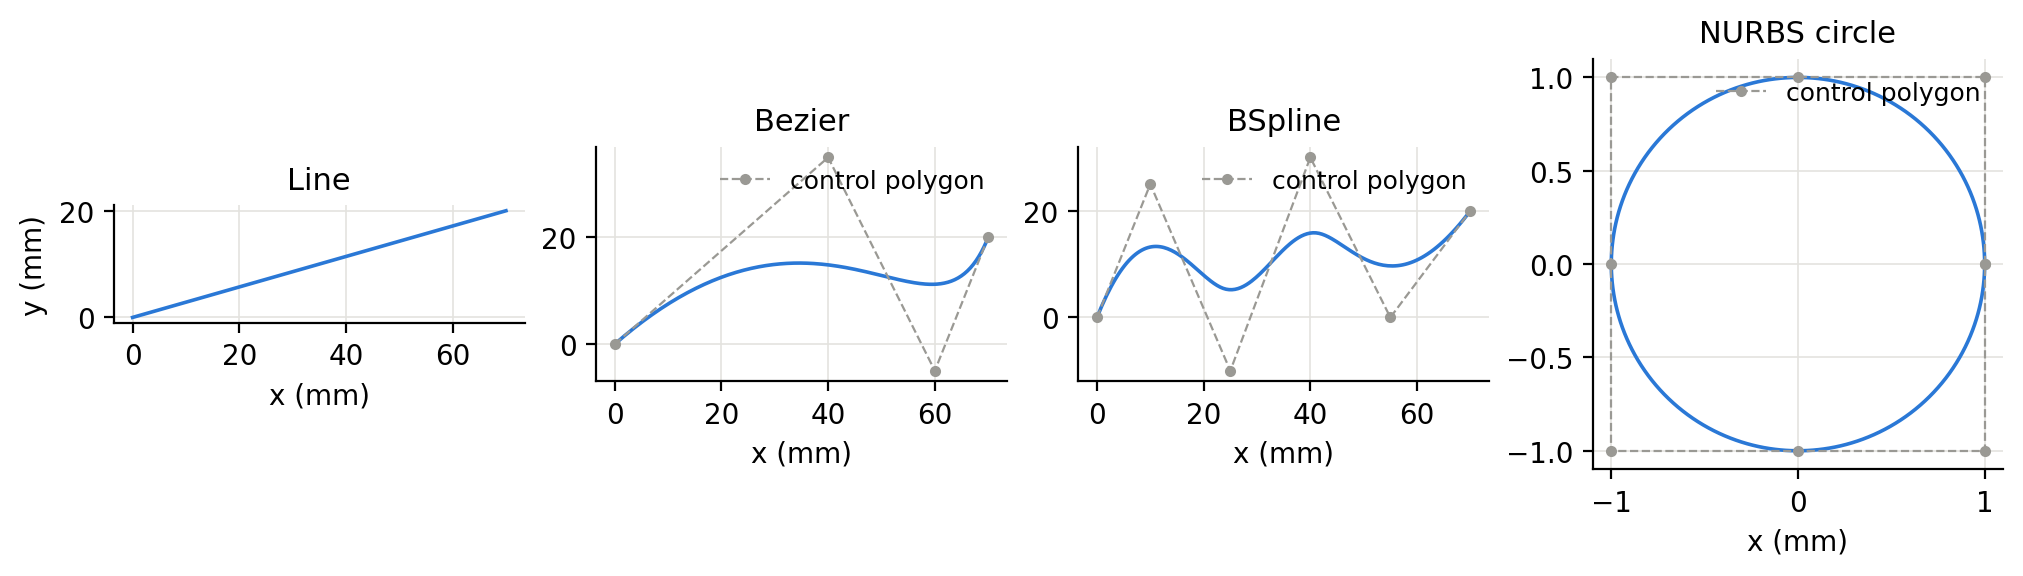

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))
for ax, c, name in zip(axes, (line, bezier, bspline, circle), ("Line", "Bezier", "BSpline", "NURBS circle")):
    p = c.sample(200)
    ax.plot(p[:, 0], p[:, 1], color=plotting.COLORS[0])
    if hasattr(c, "control_points"):
        cp = np.asarray(c.control_points)
        ax.plot(cp[:, 0], cp[:, 1], "o--", color=plotting.GRAY, ms=3, lw=0.8, label="control polygon")
        ax.legend(loc="upper right")
    ax.set_aspect("equal")
    ax.set_title(name)
    ax.set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
plt.show()

**参数等分不等于弧长等分。** 插补要的是"每个周期走同样的弧长"，而参数 $u$ 的等分点在曲线上疏密不均（参数化本身有速度起伏）。取 9 个点对比，并打印相邻点之间的弦长。

参数等分的弦长： [16.76  9.56  8.11  8.08  8.41  7.64 10.35 17.43]
弧长等分的弦长： [11.07  9.91 11.07 10.5  10.52 11.08 10.66 11.06]


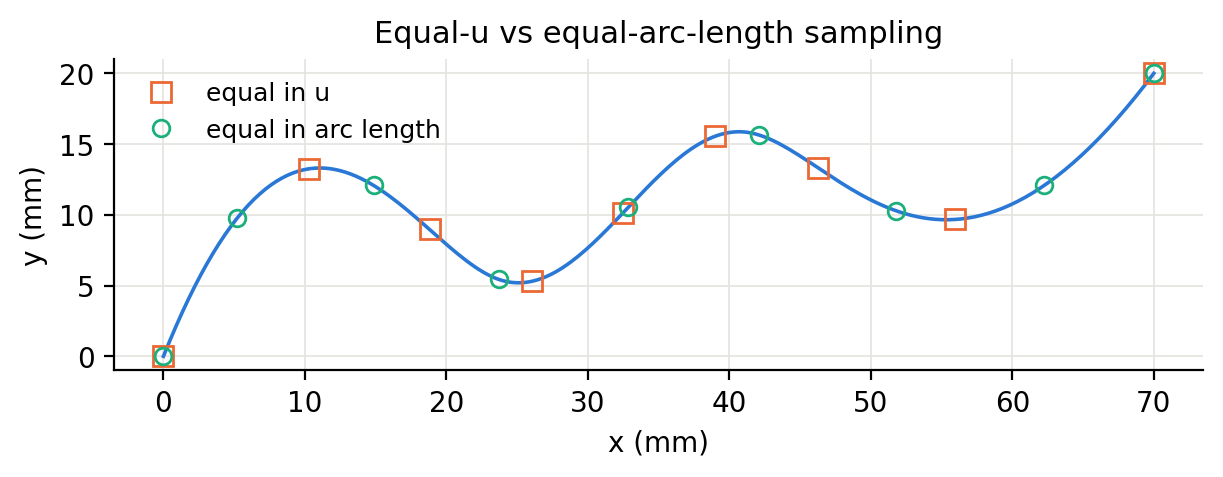

In [6]:
p_par = bspline.sample(9)
p_arc = bspline.sample(9, by_length=True)  # 内部用弧长表反解 u(s)
chords_par = np.linalg.norm(np.diff(p_par, axis=0), axis=1)
chords_arc = np.linalg.norm(np.diff(p_arc, axis=0), axis=1)
print("参数等分的弦长：", chords_par.round(2))
print("弧长等分的弦长：", chords_arc.round(2))

fig, ax = plt.subplots(figsize=(6, 3.6))
p = bspline.sample(200)
ax.plot(p[:, 0], p[:, 1], color=plotting.COLORS[0])
ax.plot(p_par[:, 0], p_par[:, 1], "s", color=plotting.COLORS[1], ms=7, mfc="none", label="equal in u")
ax.plot(p_arc[:, 0], p_arc[:, 1], "o", color=plotting.COLORS[2], ms=6, mfc="none", label="equal in arc length")
ax.set_aspect("equal")
ax.legend()
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("Equal-u vs equal-arc-length sampling")
plt.show()

参数等分的弦长差到两倍以上，弧长等分的则基本均匀（残余差别来自弦长与弧长本身不同，曲率大的地方弦略短于弧）。插补器要做的就是把"时间等分"换算成"弧长等分"——这正是弧长参数化的用武之地（第 5 节），弧长表本身的构造放在 06。

**要点**：`breaks` 给出全部可能不光滑的参数点；`sample(n, by_length=True)` 按弧长取点；NURBS 的圆没有逼近误差。

## 3. 导数栈对不对：差分参考 + 几何直观

库里的一切导数都是**解析**求出的（B 样条基函数的导数公式、NURBS 的 Leibniz 递推），差分只用来作验证的参考值。用中心差分：

$$
f'(u) \approx \frac{f(u+h)-f(u-h)}{2h} + O(h^2), \qquad
f''(u) \approx \frac{f(u+h)-2f(u)+f(u-h)}{h^2} + O(h^2).
$$

步长 $h$ 两头都有坑：太大则截断误差 $O(h^2)$ 大，太小则函数值的舍入（$\sim10^{-16}$ 量级）被 $/h$、$/h^2$ 放大。所以**每一阶各配一个步长**——一阶取 $10^{-5}$、二阶取 $10^{-4}$、三阶取 $10^{-3}$。还有一条规矩要遵守：**差分的模板不能跨过节点**——跨过真正跳变的高阶导数时，中心差分给出的既不是左极限也不是右极限（库在节点处取右极限，见第 6 节），所以把离节点比模板半径还近的点剔掉再检查。

In [7]:
def fd_check(curve, u, h1=1e-5, h2=1e-4, h3=1e-3):
    """导数栈与中心差分参考逐阶比较，返回各阶最大误差；u 须离曲线节点比 2h3 更远。"""
    f0, d = curve(u), curve.derivatives(u)
    e1 = np.abs((curve(u + h1) - curve(u - h1)) / (2 * h1) - d[1]).max()
    e2 = np.abs((curve(u + h2) - 2 * f0 + curve(u - h2)) / h2**2 - d[2]).max()
    e3 = np.abs(
        (curve(u + 2 * h3) - 2 * curve(u + h3) + 2 * curve(u - h3) - curve(u - 2 * h3)) / (2 * h3**3) - d[3]
    ).max()
    return e1, e2, e3


u = np.linspace(0.02, 0.98, 97)
for c, name in ((bspline, "BSpline"), (circle, "NURBS")):
    far = np.min(np.abs(u[:, None] - c.breaks), axis=1) > 2.5e-3  # 剔掉模板（半径 2h3）会跨界点的点
    e1, e2, e3 = fd_check(c, u[far])
    print(f"{name:8s} C′ 误差 {e1:.2e}，C″ 误差 {e2:.2e}，C‴ 误差 {e3:.2e}")
    assert e1 < 1e-5 and e2 < 1e-4 and e3 < 1e-1  # 上限就是差分自身的精度；解析导数本身远更准

BSpline  C′ 误差 1.56e-07，C″ 误差 2.69e-06，C‴ 误差 2.10e-05
NURBS    C′ 误差 6.86e-09，C″ 误差 4.58e-06，C‴ 误差 2.29e-02


几阶误差数量级递增正是差分的本性（每多除一个 $h$），不是解析导数不准。再看几何：一阶导数沿切线，二阶导数指向曲线内侧（曲率向量方向）。

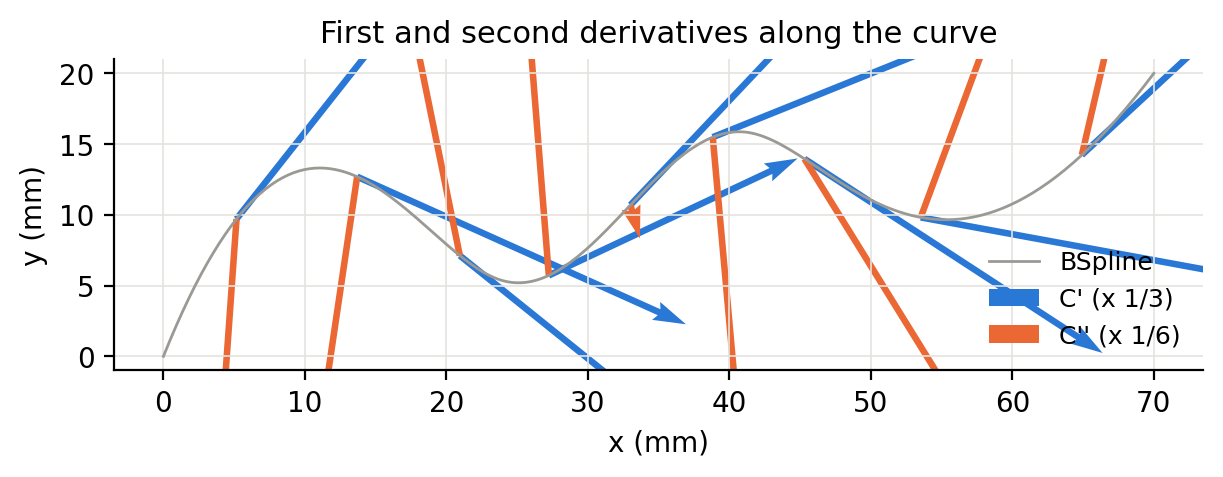

In [8]:
u_arr = np.linspace(0.06, 0.96, 9)
d = bspline.derivatives(u_arr)
fig, ax = plt.subplots(figsize=(6, 3.6))
p = bspline.sample(200)
ax.plot(p[:, 0], p[:, 1], color=plotting.GRAY, lw=1.0, label="BSpline")
ax.quiver(
    d[0, :, 0],
    d[0, :, 1],
    d[1, :, 0],
    d[1, :, 1],
    color=plotting.COLORS[0],
    angles="xy",
    scale_units="xy",
    scale=3,
    width=0.006,
    label="C' (x 1/3)",
)
ax.quiver(
    d[0, :, 0],
    d[0, :, 1],
    d[2, :, 0],
    d[2, :, 1],
    color=plotting.COLORS[1],
    angles="xy",
    scale_units="xy",
    scale=6,
    width=0.006,
    label="C'' (x 1/6)",
)
ax.set_aspect("equal")
ax.legend()
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("First and second derivatives along the curve")
plt.show()

**要点**：每条新曲线、每个新公式都拿独立参考（这里是差分）对拍一遍；一阶沿切向、二阶朝内侧，方向凭眼睛就能先排查错。

## 4. 链式法则只有一处：`calculus.compose`

把"对 $u$ 的导数"换算成"对 $t$ 的导数"，就是复合函数 $\mathbf{C}(u(t))$ 求导。到三阶的 Faà di Bruno 公式：

$$
\begin{aligned}
(\mathbf{f}\circ g)' &= \mathbf{f}'\,g',\\
(\mathbf{f}\circ g)'' &= \mathbf{f}''\,g'^2 + \mathbf{f}'\,g'',\\
(\mathbf{f}\circ g)''' &= \mathbf{f}'''\,g'^3 + 3\mathbf{f}''\,g'g'' + \mathbf{f}'\,g''' .
\end{aligned}
$$

这三行全库只写了一遍：`calculus.compose`。弧长换元（第 5 节）、刀路求值、插补、机床轴导数，全都调用它——约定里禁止再写第二份。先手写三行 numpy 做白盒对照，再让它和差分比准。

In [9]:
t = np.linspace(0.2, 2.4, 50)  # 重参数化 u = g(t) = (t/2.5)³，把 [0, 2.5] 单调映到 [0, 1]
g, g1 = (t / 2.5) ** 3, 3 * t**2 / 2.5**3
g2, g3 = 6 * t / 2.5**3, np.full_like(t, 6 / 2.5**3)

f = bspline.derivatives(g)  # 外层的导数栈（对 u）
hand = np.stack(
    [  # 白盒手写三行 Faà di Bruno（注意 numpy 广播：标量导数补一个轴）
        f[0],
        f[1] * g1[:, None],
        f[2] * g1[:, None] ** 2 + f[1] * g2[:, None],
        f[3] * g1[:, None] ** 3 + 3 * f[2] * g1[:, None] * g2[:, None] + f[1] * g3[:, None],
    ]
)
out = cx.calculus.compose(f, g1, g2, g3)
print("手写与 compose 的最大差：", np.abs(hand - out).max())
assert np.abs(hand - out).max() == 0.0

手写与 compose 的最大差： 0.0


In [10]:
ht = 1e-6  # 对 t 的差分参考：直接差分复合函数 C(g(t))
fd1 = (bspline(((t + ht) / 2.5) ** 3) - bspline(((t - ht) / 2.5) ** 3)) / (2 * ht)
print("compose 的一阶与差分参考的最大误差：", np.abs(out[1] - fd1).max())
assert np.abs(out[1] - fd1).max() < 1e-6

compose 的一阶与差分参考的最大误差： 1.4605532783207309e-08


`Reparameterized`（复合曲线类）的 `_derivatives` 就是对 `compose` 的一次调用；第 5 节的对弧长求导也是。

## 5. 对弧长求导：`derivatives_by_length`

插补要的是匀速运动（弧长随时间线性增长），所以真正需要的是 $\mathbf{C}$ 对弧长 $s$ 的导数。链式关系是 $s(u) = \int \lVert\mathbf{C}'\rVert\,\mathrm{d}u$，记 $\sigma = \lVert\mathbf{C}'\rVert$。对 $s$ 求导要用**反函数** $u(s)$ 的导数，由 $u(s(u)) = u$ 逐阶求导（`calculus.inverse_derivatives`）：

$$
u_s = \frac{1}{s'}, \qquad
u_{ss} = -\frac{s''}{s'^3}, \qquad
u_{sss} = \frac{3s''^2 - s'\,s'''}{s'^5},
$$

其中 $s' = \sigma$，$s'' = \frac{\mathbf{C}'\cdot\mathbf{C}''}{\sigma}$，$s''' = \frac{\lVert\mathbf{C}''\rVert^2+\mathbf{C}'\cdot\mathbf{C}'''-s''^2}{\sigma}$（`calculus.speed_derivatives`）。再从参数导数栈经 `compose` 换元——三步串起来就是 `curve.derivatives_by_length(u)` 的全部实现。

对弧长的导数有三个**几何恒等式**，也是最好的自检：

$$
\lVert\mathbf{C}_s\rVert \equiv 1 \quad\text{（弧长即速度为 1 的参数化）};
$$

$$
\mathbf{C}_s\cdot\mathbf{C}_{ss} \equiv 0 \quad\text{（单位向量的导数与自身垂直）};
$$

$$
\lVert\mathbf{C}_{ss}\rVert \equiv \kappa \quad\text{（二阶导数的大小就是曲率）}.
$$

在两条曲线上验证，并与 `curve.curvature`（用 $\kappa = \lVert\mathbf{C}'\times\mathbf{C}''\rVert/\lVert\mathbf{C}'\rVert^3$ 的独立实现）对比。

In [11]:
u = np.linspace(1e-7, 1 - 1e-7, 4001)
for c, name in ((bspline, "BSpline"), (circle, "NURBS circle")):
    dl = c.derivatives_by_length(u)
    e_unit = np.abs(np.linalg.norm(dl[1], axis=1) - 1).max()
    e_perp = np.abs(np.sum(dl[1] * dl[2], axis=1)).max()
    e_kap = np.abs(np.linalg.norm(dl[2], axis=1) - c.curvature(u)).max()
    print(f"{name:13s} |C_s|-1: {e_unit:.2e}   C_s·C_ss: {e_perp:.2e}   |C_ss| vs curvature: {e_kap:.2e}")
    assert e_unit < 1e-12 and e_perp < 1e-12 and e_kap < 1e-10

BSpline       |C_s|-1: 2.22e-16   C_s·C_ss: 5.55e-17   |C_ss| vs curvature: 1.11e-16
NURBS circle  |C_s|-1: 2.22e-16   C_s·C_ss: 2.64e-16   |C_ss| vs curvature: 6.66e-16


In [12]:
h = 1e-5  # 再用差分对拍一阶：按弧长等间隔取点再差分，即 dC/ds
s = bspline.length_at(u)
fd = (bspline(bspline.u_at_length(s + h)) - bspline(bspline.u_at_length(s - h))) / (2 * h)
err_fd = np.abs(fd - bspline.derivatives_by_length(u)[1]).max()
print(f"C_s 与差分参考的最大误差：{err_fd:.2e}")
assert err_fd < 1e-5

C_s 与差分参考的最大误差：2.04e-07


NURBS 圆的半径为 1，曲率应恒等于 $1$——这是有理曲线"精确成圆"的又一个佐证。B 样条的曲率 $\kappa(s)$ 沿弧长画出来，能看到控制多边形几个转折对应的峰；峰与峰之间 $\kappa$ 接近 0 的位置，就是曲线换弯的拐点。

In [13]:
kap_c = np.linalg.norm(circle.derivatives_by_length(u)[2], axis=1)
print(f"NURBS 圆 κ（= |C_ss|）∈ [{kap_c.min():.15f}, {kap_c.max():.15f}]，恒等于 1")
assert abs(kap_c.min() - 1) < 1e-14 and abs(kap_c.max() - 1) < 1e-14

NURBS 圆 κ（= |C_ss|）∈ [0.999999999999999, 1.000000000000001]，恒等于 1


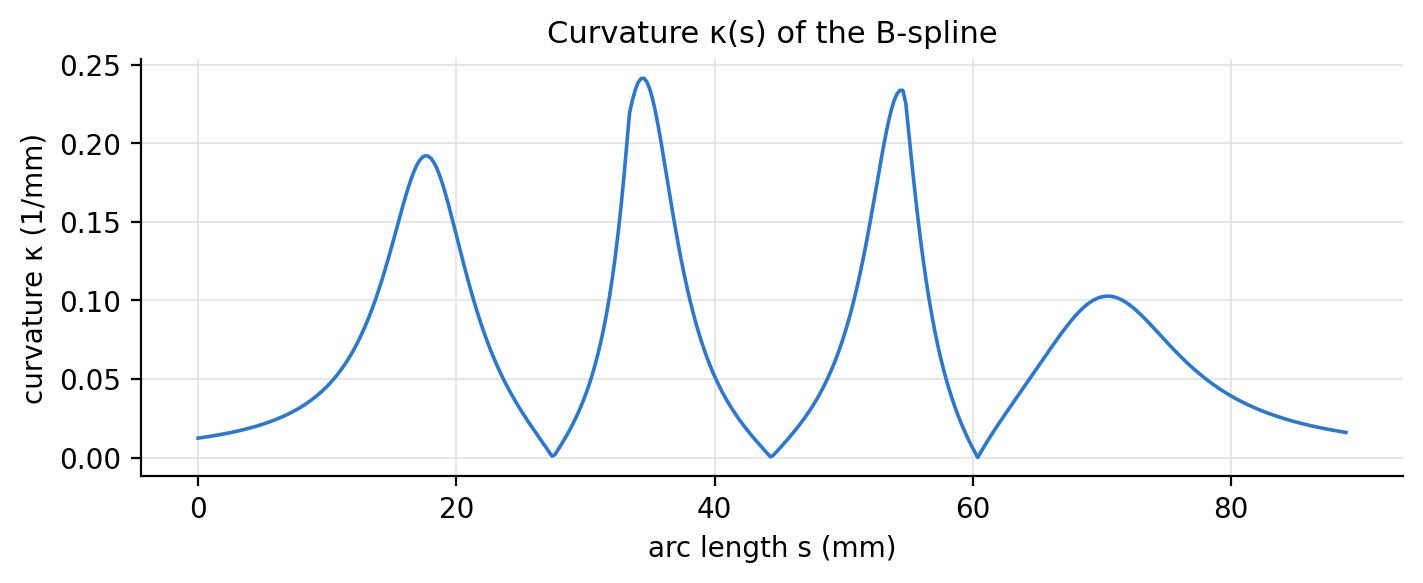

In [14]:
s_fine = np.linspace(0, bspline.length, 400)
u_fine = bspline.u_at_length(s_fine)
kappa_s = bspline.curvature(u_fine)
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(s_fine, kappa_s, color=plotting.COLORS[0])
ax.set_xlabel("arc length s (mm)")
ax.set_ylabel("curvature κ (1/mm)")
ax.set_title("Curvature κ(s) of the B-spline")
plt.show()

**要点**：对弧长求导 = 速度导数 → 反函数求导 → 链式法则，三步全是解析式；$|\mathbf{C}_s|=1$、$\mathbf{C}_s\perp\mathbf{C}_{ss}$、$|\mathbf{C}_{ss}|=\kappa$ 是日后看刀路 jerk 是否法向的判据。

## 6. breaks：曲线在哪里"不光滑"

三次 B 样条在单重内节点处是 $C^2$ 连续的：位置、切向、曲率都连续，但三阶导数 $\mathbf{C}'''$ 一般**跳变**（连续性降阶规则：重数为 $m$ 的节点处只保证 $C^{p-m}$）。把 $\mathbf{C}'''$ 的 $y$ 分量画出来，节点处是台阶。注意**节点不一定是曲线上显眼的位置**——它是参数域的属性，图上用灰色竖线标参数值。

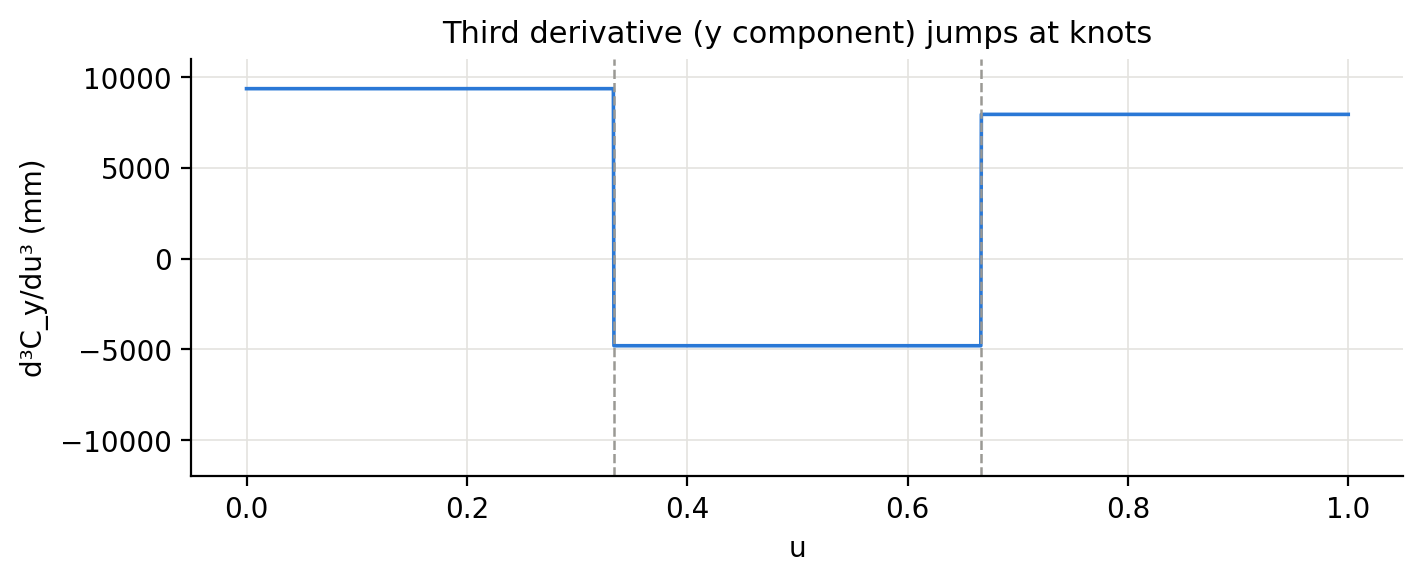

u = 0.3333 处 C‴ 的跳变：(   202.5,  -14175.0) mm
u = 0.6667 处 C‴ 的跳变：(   607.5,   12757.5) mm


In [15]:
u_fine = np.linspace(0, 1, 2001)
c3 = bspline.derivative(u_fine, 3)  # curve.derivative(u, k) 只取第 k 阶
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(u_fine, c3[:, 1], color=plotting.COLORS[0])
for b_ in bspline.breaks[1:-1]:
    ax.axvline(b_, color=plotting.GRAY, ls="--", lw=0.9)
ax.set_ylim(-12000, 11000)  # 截去首段的尖峰，让两个节点处的台阶可辨
ax.set_xlabel("u")
ax.set_ylabel("d³C_y/du³ (mm)")
ax.set_title("Third derivative (y component) jumps at knots")
plt.show()

for b_ in bspline.breaks[1:-1]:  # 用 ±1e-9 的邻值逼近左右极限（库在内部节点处取右极限）
    left = bspline.derivative(b_ - 1e-9, 3)
    right = bspline.derivative(b_ + 1e-9, 3)
    print(f"u = {b_:.4f} 处 C‴ 的跳变：({right[0] - left[0]:8.1f}, {right[1] - left[1]:9.1f}) mm")

图里两处的台阶就是跳变本身（起点附近更高的一段是夹持端点效应，与节点无关，为避免它压缩视野，纵轴做了截断）。

**为什么 `breaks` 必须包含所有不光滑点**：弧长表先按 `breaks` 分段，再逐段做 Gauss 积分与 Hermite 插值（第 2 节打印过 `breaks` 为 [0, 1/3, 2/3, 1]）——跨过跳变点的数值积分收敛很慢、多项式插值则根本不成立；后面 03 的前瞻扫描、04 的速度规划也都按 block 分段处理。新曲线类如果忘了把不光滑点报进 `breaks`，毛病不会立刻爆炸，而是弧长、限速这些下游量悄悄变差。

**要点**：B 样条节点处三阶导数跳变不是 bug，是定义；`breaks` 让所有下游算法绕开这些点。

## 7. 切分：一条曲线变两条

速度规划常要在某点把曲线剪开（例如把曲率峰值设为 block 分界）。cnc5x 有两把剪子：

- **`Bezier.split(u)`**：手写 de Casteljau——逐层线性插值，每层的端点恰好是两段的控制点。这几行本身就是原理，所以自己写；
- **`BSpline.split(u)`**：节点插入（Boehm 算法）把 $u$ 的重数补到 $p$，曲线在 $u$ 处恰好经过一个控制点，沿它剪开。这是数值内核，调 `scipy.interpolate.insert`（与求值同一取舍，见 CLAUDE.md §5）。

更轻的办法是 **`SubCurve`**：不切控制点，只把参数域收窄到 $[a,b]$，求值转发给原曲线，并把区间内的 `breaks` 继承下来——在临界点处切 block 用的就是它。

先验证三者切出的是**同一条几何**：两段拼起来与原曲线逐点一致（B 样条被切的参数取 0.5，Bézier 取 0.42）。

In [16]:
us = 0.5
bl, br = bezier.split(0.42)
sl, sr = bspline.split(us)
sub_l, sub_r = cx.SubCurve(bspline, 0.0, us), cx.SubCurve(bspline, us, 1.0)

u = np.linspace(0, 1, 2001)
left_u, right_u = u[u <= us], u[u >= us]
err_split = max(
    np.abs(bspline(left_u) - sl(left_u)).max(),
    np.abs(bspline(right_u) - sr(right_u)).max(),
)
err_sub = max(
    np.abs(bspline(left_u) - sub_l(left_u)).max(),
    np.abs(bspline(right_u) - sub_r(right_u)).max(),
)
print(f"BSpline.split 拼接最大误差 {err_split:.2e} mm")
print(f"SubCurve 截取最大误差   {err_sub:.2e} mm")
assert err_split < 1e-10 and err_sub == 0.0  # split 只剩节点插入的舍入；SubCurve 是原样转发
print(f"两段弧长之和 − 原弧长 = {sl.length + sr.length - bspline.length:.2e} mm")

BSpline.split 拼接最大误差 2.84e-14 mm


SubCurve 截取最大误差   0.00e+00 mm


两段弧长之和 − 原弧长 = -5.68e-14 mm


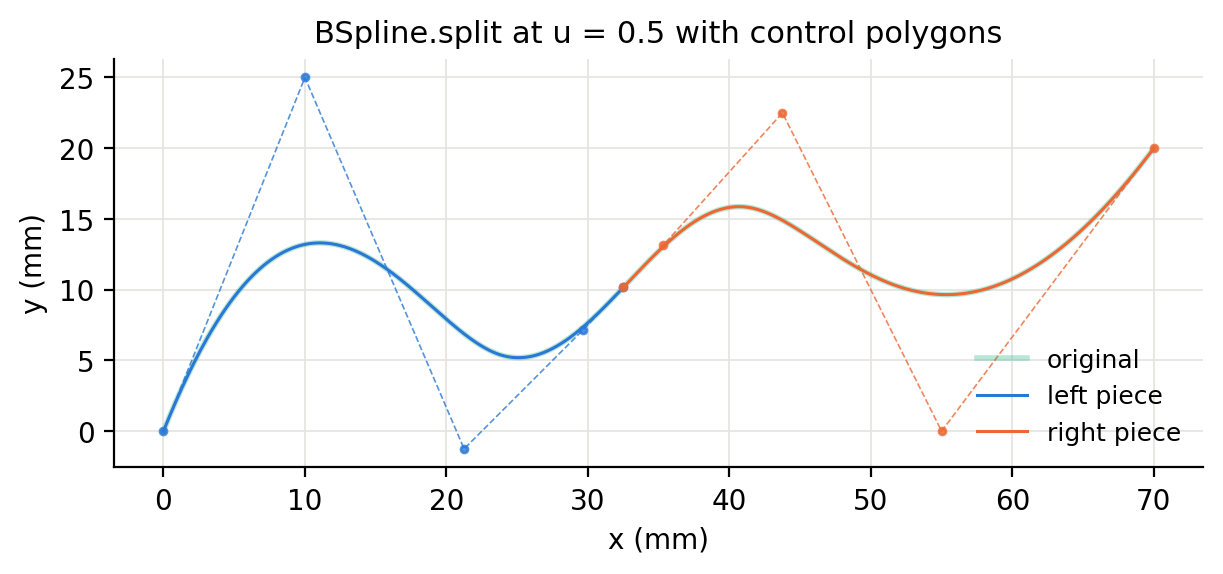

In [17]:
fig, ax = plt.subplots(figsize=(6, 3.6))
p = bspline.sample(200)
ax.plot(p[:, 0], p[:, 1], lw=2.0, alpha=0.3, color=plotting.COLORS[2], label="original")
for seg, c, name in ((sl, plotting.COLORS[0], "left"), (sr, plotting.COLORS[1], "right")):
    q = np.linspace(*seg.domain, 400, endpoint=False)  # 避开右侧端点；scipy 在节点处不支持批量插值
    ps = np.vstack([seg(q), seg(seg.domain[1])])  # 终点单独求（标量 clip 没问题）
    ax.plot(ps[:, 0], ps[:, 1], color=c, lw=1.1, label=f"{name} piece")
    cp = seg.control_points
    ax.plot(cp[:, 0], cp[:, 1], "o--", color=c, ms=2.5, lw=0.6, alpha=0.8)
ax.set_aspect("equal")
ax.legend()
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("BSpline.split at u = 0.5 with control polygons")
plt.show()

两半各自有了自己的控制多边形（因节点插入而加密），几何却与原曲线严丝合缝。Bezier 的 de Casteljau 分段同理，留作练习。

**要点**：`split` 改控制点、`SubCurve` 改参数域，都是精确切分，不引入逼近误差——所以 block 边界处的前后衔接不缺精度。

## 8. 练习

1. 把第 2 节的 B 样条换成**非均匀节点**（如 `knots=[0,0,0,0,0.2,0.5,0.5,1,1,1,1]`，控制点减一个），重新画第 6 节的 $\mathbf{C}'''$ 图：重数为 2 的节点处 $C''$ 也开始跳了，能看出连续性降了一阶。
2. 在 `Bezier.split` 上验证 de Casteljau：对第 2 节的 Bézier 在若干个 $u$ 切分，断言两段的拼接误差为零；再检查左右两段的控制点数之和是 $2(n+1)$，并验证 `bl(1)` 与 `br(0)` 同为原曲线在 $u$ 处的点。
3. 手工算一次 NURBS 圆在 $u = 0$ 处的 $\mathbf{C}'$（提示：端点处 $\mathbf{C}'(0)=\frac{p\,w_1}{w_0}(\mathbf{P}_1-\mathbf{P}_0)$），与 `circle.derivative(0, 1)` 对比。
4. 把第 4 节的重参数化换成 $g(t) = \sin(\pi t/5)$（不严格单调！），在 compose 验证里观察误差在哪里爆掉；再试 `cx.Reparameterized(bspline, ...)` 会不会报"映射必须严格递增"。

## 延伸阅读

- [docs/数学约定.md](../docs/数学约定.md) §1（导数栈）、§2（曲线与弧长、反函数求导的完整推导）；
- 本系列的 02（ToolPath 与 block）、06（弧长表与速度规划）：本节只消费了 `length` 与 `u_at_length`，它们背后的自适应求积在那里展开；
- The NURBS Book（Piegl & Tiller）第 2–5 章：B 样条求导、有理曲线的导数递推与节点插入；
- 五轴里曲线的另一面——刀轴曲线（`GreatCircle`、`SphericalCurve` 等）作为"单位球面上的曲线"复用本节的全部机制，见 `orientation.py`。